# 量子ニューラルネットワークを用いた回帰

本チュートリアルでは`scikit-quri`および`quri-parts`を使用して、量子ニューラルネットワークにより回帰問題を解く方法を解説します。

## 量子ニューラルネットワークとは
近年、古典コンピュータと量子コンピュータを組み合わせて動作するハイブリッドアルゴリズムが注目されています。その中でも代表的なアプローチの一つが、今回扱う「量子ニューラルネットワーク（Quantum Neural Network: QNN）」です。QNNとは、変分量子回路（Variational Quantum Circuit: VQC）を機械学習モデルとして利用する手法のことです。一般的な（古典）ニューラルネットワークが、層間の結合強度である「重み」や「バイアス」を学習によって更新するのと同様に、QNNでは「量子回路内のゲートパラメータ（回転角など）」を学習対象とします。 入力データを量子状態に埋め込み、パラメータ付き量子回路で変換を行い、その測定結果をもとに損失関数を最小化するようにパラメータを最適化します。これにより、複雑な関数の近似や分類タスクを行うことが可能になります。

## 本チュートリアルのゴール
本チュートリアルでは、QNNを用いた具体的なタスクとして、「ノイズのある正弦波（sin関数）の回帰」に取り組みます。

具体的には以下のステップで進めます。
1. ノイズを含んだsin関数のデータセットを生成する
2. `scikit-quri`を用いて、学習可能な量子回路（Ansatz）を構築する
3. `quri-parts`を用いて、期待値計算に用いるEstimatorを定義する
4. `scikit-quri`を用いて学習を行う
5. 未知のテストデータに対して回帰を行い学習したモデルを評価する

## データセットの生成

まず、学習および評価に使用するデータセットを生成します。 ここでは、正弦波 $y=\sin(\pi x)$ に対して一様乱数によるノイズを加えたデータを生成します。

In [2]:
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt

def generate_noisy_sine(x_min, x_max, num_x):
    rng = default_rng(0)
    x_train = [[rng.uniform(x_min, x_max)] for _ in range(num_x)]
    y_train = [np.sin(np.pi * x[0]) for x in x_train]
    mag_noise = 0.01
    y_train += mag_noise * rng.random(num_x)
    return np.array(x_train).flatten(), np.array(y_train)

x_all, y_all = generate_noisy_sine(-1.0, 1.0, 160)
num_train = 80
x_train, x_test = x_all[:num_train], x_all[num_train:]
y_train, y_test = y_all[:num_train], y_all[num_train:]



生成された学習データをプロットしてみると以下のようになります。青い点が学習データ、緑の点がテストデータ、赤い線がノイズのない真の$\sin(\pi x)$を表しています。

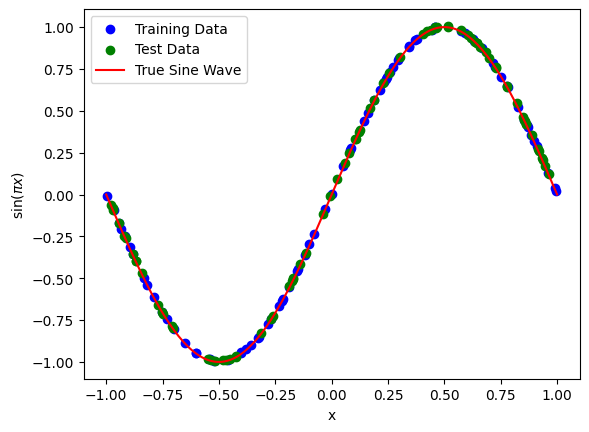

In [3]:
plt.scatter(x_train, y_train, color='blue', label='Training Data')
plt.scatter(x_test, y_test, color='green', label='Test Data')
x_true = np.linspace(-1.0, 1.0, 200)
y_true = np.sin(np.pi * x_true)
plt.plot(x_true, y_true, color='red', label='True Sine Wave')
plt.xlabel('x')
plt.ylabel(r'$\sin(\pi x)$')
plt.legend()
plt.show()

## Ansatzの構築
次に、QNNのモデル構造に相当するAnsatzを構築します。Ansatzとは、QNNの文脈ではパラメータによって調整可能な量子回路を指します。古典的ニューラルネットワークにおいて層の数や結合の仕方を決めるのと同様に、QNNでも「どのようなゲートを、どのような順序で配置するか」をあらかじめ決めておきます。この回路に含まれる回転ゲートの角度（パラメータ）を学習によって最適化することで、所望の機能を実現します。

ここでは、`scikit-quri`の`create_qcl_ansatz`を用いてAnsatzを作成します。 qubit数、回路の深さ（繰り返し回数）、ハミルトニアンダイナミクスの時間発展時間、random関数のseedを設定して回路を生成します。

In [4]:
from scikit_quri.circuit.pre_defined import create_qcl_ansatz

n_qubits = 5
depth = 6
parametric_circuit = create_qcl_ansatz(n_qubits, depth, 0.5, 0)

作成された量子回路を可視化すると以下のようになります。この量子回路は大きく分けて、「データを量子状態に埋め込む部分」と「最適化される変文量子回路の部分」で構成されています。

まず「データを量子状態を埋め込む部分」は、入力データ$x$をパラメータとして持つ$R_Y$ゲートと$R_Z$ゲートで構成されます。これにより、古典入力データ$x$が埋め込まれた量子状態が作られます。

その後の「最適化される変文量子回路の部分」は、ランダムハミルトニアンによる時間発展と、回転ゲート（$R_X$ゲートと$R_Z$ゲート）で構成され、これらがdepth回繰り返されます。ランダムハミルトニアンによる時間発展は、エンタングルメントを生成し、モデルの表現力を高める役割を持ちます。この部分は学習パラメータを持ちません。回転ゲートは学習パラメータを持ち、このパラメータを調整することで回路の出力が教師データ$y$に近づくようにします。

In [5]:
from quri_parts.circuit.utils.circuit_drawer import draw_circuit

draw_circuit(parametric_circuit.circuit)

   ___     ___     ___     ___     ___     ___     ___     ___     ___     ___  
  |PRY|   |PRZ|   |Mat|   |PRX|   |PRZ|   |PRX|   |Mat|   |PRX|   |PRZ|   |PRX| 
--|0  |---|1  |---|10 |---|11 |---|12 |---|13 |---|26 |---|27 |---|28 |---|29 |-
  |___|   |___|   |   |   |___|   |___|   |___|   |   |   |___|   |___|   |___| 
   ___     ___    |   |    ___     ___     ___    |   |    ___     ___     ___  
  |PRY|   |PRZ|   |   |   |PRX|   |PRZ|   |PRX|   |   |   |PRX|   |PRZ|   |PRX| 
--|2  |---|3  |---|   |---|14 |---|15 |---|16 |---|   |---|30 |---|31 |---|32 |-
  |___|   |___|   |   |   |___|   |___|   |___|   |   |   |___|   |___|   |___| 
   ___     ___    |   |    ___     ___     ___    |   |    ___     ___     ___  
  |PRY|   |PRZ|   |   |   |PRX|   |PRZ|   |PRX|   |   |   |PRX|   |PRZ|   |PRX| 
--|4  |---|5  |---|   |---|17 |---|18 |---|19 |---|   |---|33 |---|34 |---|35 |-
  |___|   |___|   |   |   |___|   |___|   |___|   |   |   |___|   |___|   |___| 
   ___     ___    |   |    _

## Estimatorの準備

回路からの出力を数値として取り出すためには、オブザーバブル（観測量）の期待値を計算する必要があります。`quri-parts`では、この期待値計算を行うためのインターフェースとして`Estimator`が用意されています。ここでは、以下の2種類の`Estimator`を定義します。

estimator: 回路の出力（期待値）そのものを計算します。学習時のコスト関数の計算や、学習後の推論に使用します。

gradient_estimator: パラメータに対する期待値の勾配を計算します。これは、パラメータをどの方向に更新すればよいかを知るため（学習）に必要です。

In [6]:
from quri_parts.core.estimator.gradient import create_numerical_gradient_estimator
from quri_parts.qulacs.estimator import (
    create_qulacs_vector_concurrent_parametric_estimator,
    create_qulacs_vector_concurrent_estimator,
)

estimator = create_qulacs_vector_concurrent_estimator()
gradient_estimator = create_numerical_gradient_estimator(
    create_qulacs_vector_concurrent_parametric_estimator(), delta=1e-10
)

## 学習

`scikit-quri`の`QNNRegressor`クラスを使用し、AnsatzとEstimatorから回帰モデルを構成します。ここでは最適化に、機械学習で広く使われているAdamを採用します。`fit`メソッドを用いると学習が行われます。

In [7]:
from scikit_quri.qnn.regressor import QNNRegressor
from quri_parts.algo.optimizer import Adam

adam = Adam()
qnn = QNNRegressor(parametric_circuit, estimator, gradient_estimator, adam)
qnn.fit(x_train, y_train, maxiter=30)


LearningCircuit(n_qubits=5, circuit=<quri_parts.rust.circuit.circuit_parametric.ParametricQuantumCircuit object at 0x114f20090>, input_functions={0: <function create_qcl_ansatz.<locals>.<lambda> at 0x114bc01f0>, 1: <function create_qcl_ansatz.<locals>.<lambda> at 0x114afe560>, 2: <function create_qcl_ansatz.<locals>.<lambda> at 0x114f16050>, 3: <function create_qcl_ansatz.<locals>.<lambda> at 0x114f160e0>, 4: <function create_qcl_ansatz.<locals>.<lambda> at 0x114f16170>, 5: <function create_qcl_ansatz.<locals>.<lambda> at 0x114f16200>, 6: <function create_qcl_ansatz.<locals>.<lambda> at 0x114f16290>, 7: <function create_qcl_ansatz.<locals>.<lambda> at 0x114f16320>, 8: <function create_qcl_ansatz.<locals>.<lambda> at 0x114f163b0>, 9: <function create_qcl_ansatz.<locals>.<lambda> at 0x114f16440>}, _input_parameter_list=[_InputParameter(pos=0, func=<function create_qcl_ansatz.<locals>.<lambda> at 0x114bc01f0>, companion_parameter_id=None), _InputParameter(pos=1, func=<function create_qcl_

## 予測と評価

最後に、学習済みモデルの性能を評価します。モデルが学習データに含まれていない未知のデータ（テストデータ）に対して、どの程度正確に元の関数形状を捉えられているかを確認します。評価には、一般的な回帰問題と同様に 平均二乗誤差 (Mean Squared Error: MSE) を使用します。 predictメソッドを使用することで、学習済みのパラメータを用いて入力データに対する予測値を出力できます。

以下では、ノイズを含んだテスト教師データ（Test）、ノイズのない真の正弦波（True）、学習済みのQNNによる予測結果（Prediction）をプロットしています。

loss=0.001536460329725406


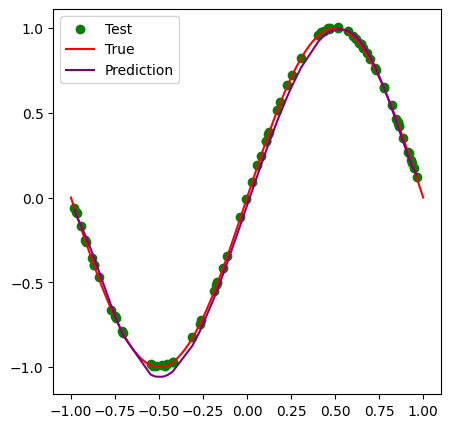

In [11]:
from sklearn.metrics import mean_squared_error
y_pred = qnn.predict(x_test)
y_test = y_test.reshape(-1, 1)
plt.figure(figsize=(5, 5))
plt.scatter(np.sort(x_test.flatten()), y_test[np.argsort(x_test.flatten())], color="green", label="Test")

x_true = np.linspace(-1, 1, 100)
y_true = np.sin(np.pi * x_true)
plt.plot(x_true, y_true, color="red", label="True")
plt.plot(np.sort(x_test.flatten()), y_pred[np.argsort(x_test.flatten())], color="purple", label="Prediction")
plt.legend()

loss = mean_squared_error(y_test, y_pred)
print(f"{loss=}")
plt.show()